In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/Crop Yeild Data.csv")
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [7]:
df.shape

(19689, 13)

In [8]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield',
       'Avg_Temperature', 'Max_Temperature', 'Min_Temperature'],
      dtype='object')

In [9]:
categorical_cols = ["Crop", "Season", "State"]

for col in categorical_cols:
    df[col] = df[col].str.strip()

In [10]:
df["Season"].unique()

array(['Whole Year', 'Kharif', 'Rabi', 'Autumn', 'Summer', 'Winter'],
      dtype=object)

In [11]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64

In [12]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [13]:
df["Season"].unique()

array(['Whole Year', 'Kharif', 'Rabi', 'Autumn', 'Summer', 'Winter'],
      dtype=object)

In [14]:
# Check the data type of every column
df.dtypes

Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
Avg_Temperature    float64
Max_Temperature    float64
Min_Temperature    float64
dtype: object

In [15]:
# Check whether the dataset contains duplicate rows
df.duplicated().sum()

0

In [16]:
# Count missing values in each column
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64

In [17]:
# Show basic statistics of the target variable
df["Yield"].describe()

count    19689.000000
mean        79.954011
std        878.306194
min          0.000000
25%          0.600000
50%          1.030000
75%          2.389000
max      21105.000000
Name: Yield, dtype: float64

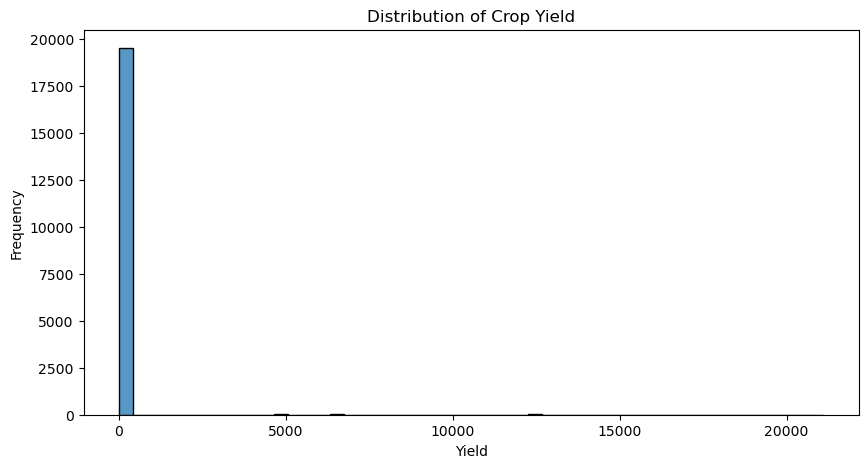

In [15]:
# Plot the distribution of crop yield
plt.figure(figsize=(10, 5))

sns.histplot(df["Yield"], bins=50)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()

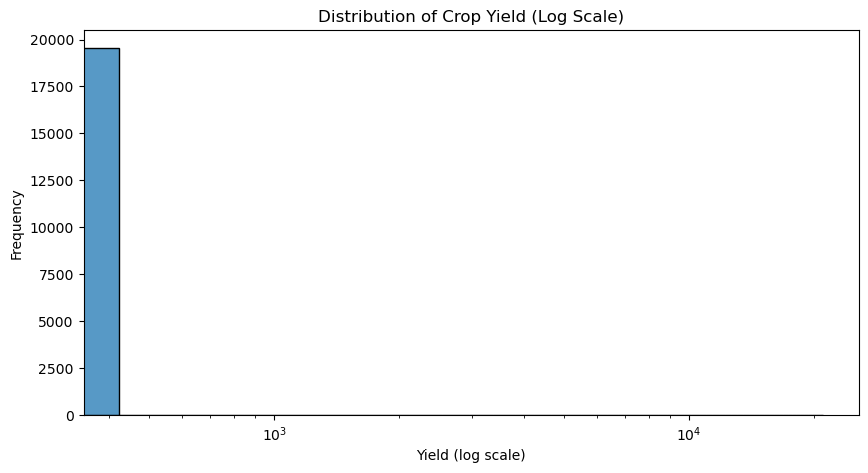

In [18]:
# Plot Yield on a log scale to see the distribution more clearly
plt.figure(figsize=(10, 5))

sns.histplot(df["Yield"], bins=50)

plt.xscale("log")

plt.title("Distribution of Crop Yield (Log Scale)")
plt.xlabel("Yield (log scale)")
plt.ylabel("Frequency")

plt.show()

In [19]:
# Calculate the average yield for each crop
crop_yield = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False)

crop_yield.head(15)

Crop
Coconut         8652.000215
Sugarcane         51.727451
Banana            26.851143
Tapioca           16.667318
Potato            13.331720
Onion             13.247509
Sweet potato       9.240795
Jute               7.555398
Ginger             6.442226
Mesta              5.389195
Garlic             4.544880
Maize              3.427209
Turmeric           3.325374
Cashewnut          3.120455
Bajra              2.427456
Name: Yield, dtype: float64

In [20]:
# Calculate the median yield for each crop
crop_median_yield = df.groupby("Crop")["Yield"].median().sort_values(ascending=False)

crop_median_yield.head(15)

Crop
Coconut         8466.3155
Sugarcane         53.1580
Banana            17.9490
Tapioca           11.1180
Potato            10.1755
Onion              9.1930
Sweet potato       8.5130
Jute               8.1460
Mesta              4.9350
Ginger             4.8880
Garlic             3.3065
Rice               2.2040
Turmeric           2.0160
Maize              1.9550
Wheat              1.6680
Name: Yield, dtype: float64

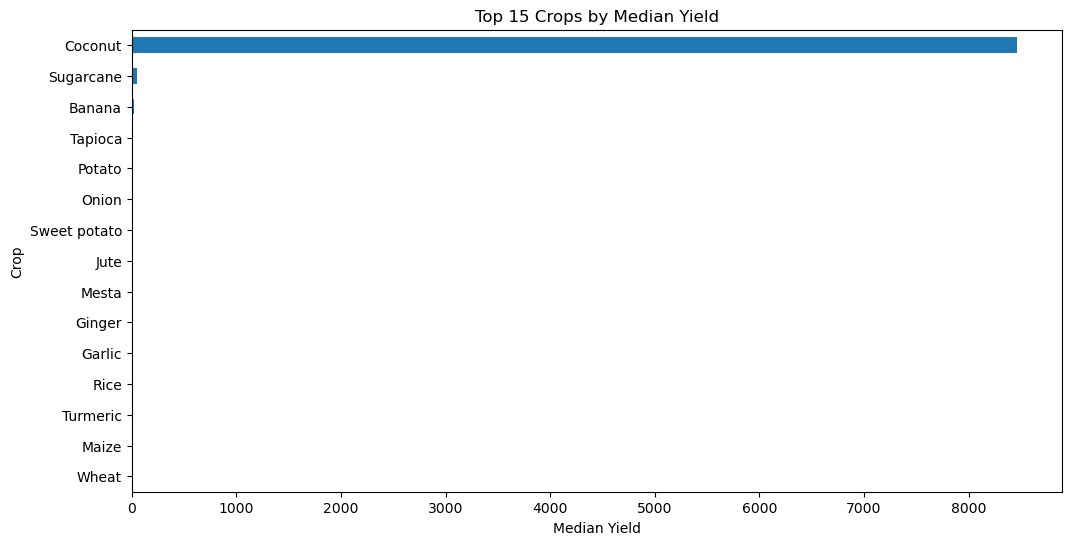

In [19]:
# Plot the 15 crops with the highest median yield
plt.figure(figsize=(12, 6))

crop_median_yield.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Crops by Median Yield")
plt.xlabel("Median Yield")
plt.ylabel("Crop")

plt.show()

In [21]:
# Count how many observations exist for each crop
crop_counts = df["Crop"].value_counts()

crop_counts.head(15)

Crop
Rice                 1197
Maize                 975
Moong(Green Gram)     740
Urad                  733
Groundnut             725
Sesamum               685
Potato                628
Sugarcane             605
Wheat                 545
Rapeseed &Mustard     528
Bajra                 524
Jowar                 513
Arhar/Tur             508
Ragi                  498
Gram                  490
Name: count, dtype: int64

In [22]:
# Select numerical features that we may use for prediction
numeric_features = [
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Avg_Temperature",
    "Max_Temperature",
    "Min_Temperature"
]

numeric_features

['Area',
 'Annual_Rainfall',
 'Fertilizer',
 'Pesticide',
 'Avg_Temperature',
 'Max_Temperature',
 'Min_Temperature']

In [23]:
# Calculate how strongly each numerical feature is related to Yield
correlations = df[numeric_features + ["Yield"]].corr()["Yield"].sort_values(ascending=False)

correlations

Yield              1.000000
Min_Temperature    0.057606
Avg_Temperature    0.039341
Annual_Rainfall    0.020761
Max_Temperature    0.018742
Fertilizer         0.002862
Area               0.001858
Pesticide          0.001782
Name: Yield, dtype: float64

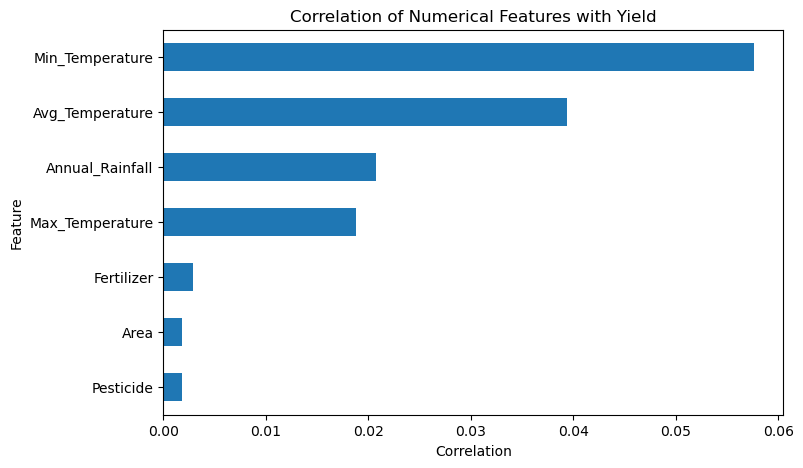

In [24]:
# Plot the correlation of numerical features with Yield
plt.figure(figsize=(8, 5))

correlations.drop("Yield").sort_values().plot(kind="barh")

plt.title("Correlation of Numerical Features with Yield")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [25]:
# Create a correlation matrix for the numerical features and Yield
corr_matrix = df[numeric_features + ["Yield"]].corr()

corr_matrix

,Area,Annual_Rainfall,Fertilizer,Pesticide,Avg_Temperature,Max_Temperature,Min_Temperature,Yield
Area,1.000000,-0.106054,0.973255,0.973479,0.082809,0.113578,0.042066,0.001858
Annual_Rainfall,-0.106054,1.000000,-0.109734,-0.097657,-0.217055,-0.373679,-0.063674,0.020761
Fertilizer,0.973255,-0.109734,1.000000,0.954991,0.085120,0.116242,0.042809,0.002862
Pesticide,0.973479,-0.097657,0.954991,1.000000,0.077582,0.106834,0.038657,0.001782
Avg_Temperature,0.082809,-0.217055,0.085120,0.077582,1.000000,0.960135,0.963462,0.039341
Max_Temperature,0.113578,-0.373679,0.116242,0.106834,0.960135,1.000000,0.855896,0.018742
Min_Temperature,0.042066,-0.063674,0.042809,0.038657,0.963462,0.855896,1.000000,0.057606
Yield,0.001858,0.020761,0.002862,0.001782,0.039341,0.018742,0.057606,1.000000


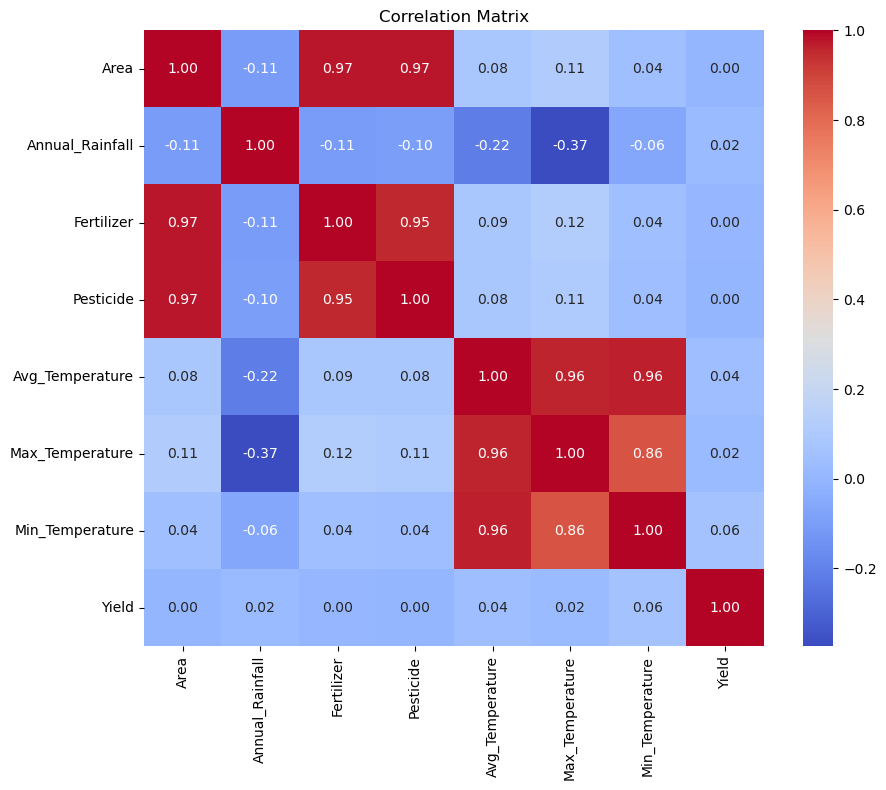

In [26]:
# Display the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

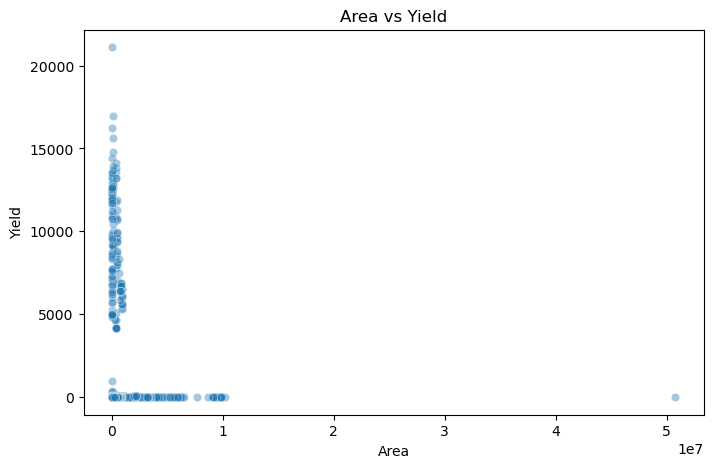

In [27]:
# Plot the relationship between cultivated area and yield
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Area", y="Yield", alpha=0.4)

plt.title("Area vs Yield")
plt.xlabel("Area")
plt.ylabel("Yield")

plt.show()

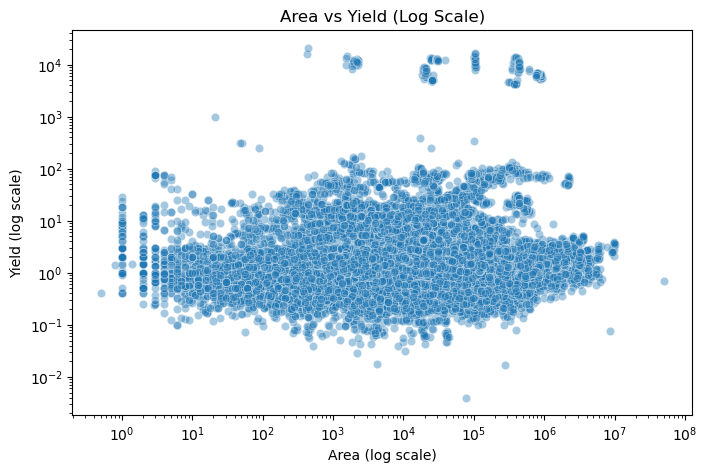

In [28]:
# Use log scales to make the wide range of values easier to see
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Area", y="Yield", alpha=0.4)

plt.xscale("log")
plt.yscale("log")

plt.title("Area vs Yield (Log Scale)")
plt.xlabel("Area (log scale)")
plt.ylabel("Yield (log scale)")

plt.show()

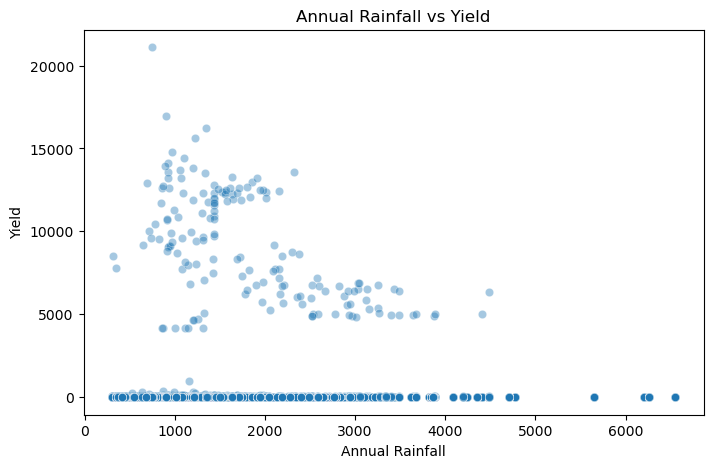

In [29]:
# Plot the relationship between rainfall and yield
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Annual_Rainfall", y="Yield", alpha=0.4)

plt.title("Annual Rainfall vs Yield")
plt.xlabel("Annual Rainfall")
plt.ylabel("Yield")

plt.show()

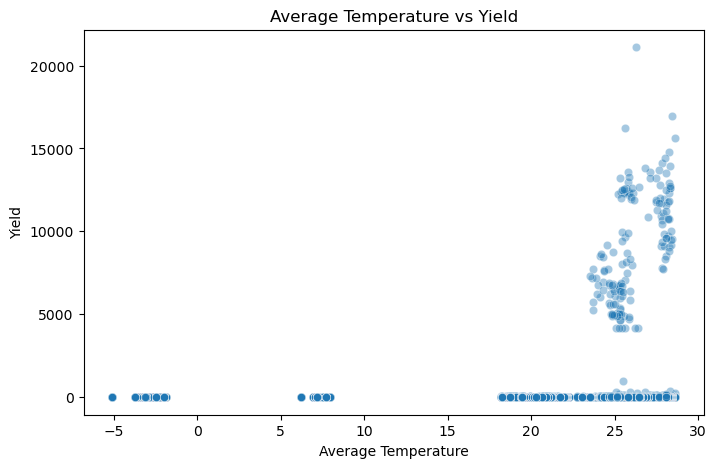

In [30]:
# Plot the relationship between average temperature and yield
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Avg_Temperature", y="Yield", alpha=0.4)

plt.title("Average Temperature vs Yield")
plt.xlabel("Average Temperature")
plt.ylabel("Yield")

plt.show()

In [31]:
# Remove unwanted spaces from categorical columns
for col in ["Crop", "Season", "State"]:
    df[col] = df[col].str.strip()

# Check the cleaned values
print(df[["Crop", "Season", "State"]].head())

           Crop      Season  State
0      Arecanut  Whole Year  Assam
1     Arhar/Tur      Kharif  Assam
2   Castor seed      Kharif  Assam
3       Coconut  Whole Year  Assam
4  Cotton(lint)      Kharif  Assam


In [32]:
# Calculate the average yield for each crop
crop_mean_yield = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False)

# Display the top 15 crops
print(crop_mean_yield.head(15))

Crop
Coconut         8652.000215
Sugarcane         51.727451
Banana            26.851143
Tapioca           16.667318
Potato            13.331720
Onion             13.247509
Sweet potato       9.240795
Jute               7.555398
Ginger             6.442226
Mesta              5.389195
Garlic             4.544880
Maize              3.427209
Turmeric           3.325374
Cashewnut          3.120455
Bajra              2.427456
Name: Yield, dtype: float64


In [33]:
# Calculate the median yield for each crop
crop_median_yield = df.groupby("Crop")["Yield"].median().sort_values(ascending=False)

# Display the top 15 crops
print(crop_median_yield.head(15))

Crop
Coconut         8466.3155
Sugarcane         53.1580
Banana            17.9490
Tapioca           11.1180
Potato            10.1755
Onion              9.1930
Sweet potato       8.5130
Jute               8.1460
Mesta              4.9350
Ginger             4.8880
Garlic             3.3065
Rice               2.2040
Turmeric           2.0160
Maize              1.9550
Wheat              1.6680
Name: Yield, dtype: float64


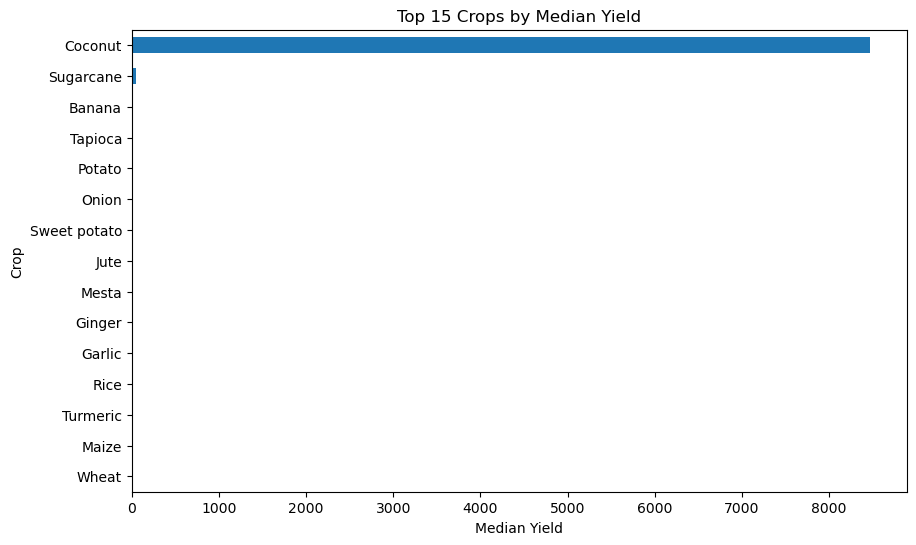

In [34]:
# Plot the 15 crops with the highest median yield
plt.figure(figsize=(10, 6))

crop_median_yield.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Crops by Median Yield")
plt.xlabel("Median Yield")
plt.ylabel("Crop")

plt.show()

In [35]:
# Calculate the average and median yield for each season
season_yield = df.groupby("Season")["Yield"].agg(["count", "mean", "median"])

# Sort by median yield
season_yield = season_yield.sort_values("median", ascending=False)

print(season_yield)

            count        mean  median
Season                               
Whole Year   3717  412.995471   4.295
Summer       1195    2.997367   1.674
Winter        389    5.287262   1.545
Autumn        414    3.917498   1.092
Kharif       8232    2.482003   0.924
Rabi         5742    1.988516   0.903


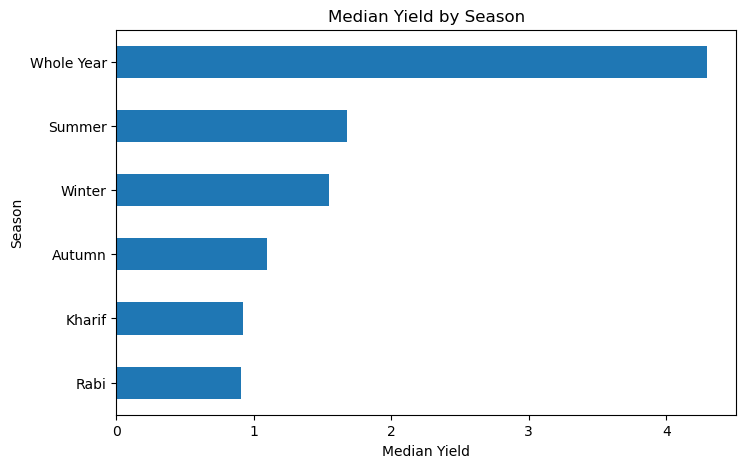

In [36]:
# Compare median yield across different seasons
plt.figure(figsize=(8, 5))

season_yield["median"].sort_values().plot(kind="barh")

plt.title("Median Yield by Season")
plt.xlabel("Median Yield")
plt.ylabel("Season")

plt.show()

In [37]:
# Calculate average and median yield for each state
state_yield = df.groupby("State")["Yield"].agg(["count", "mean", "median"])

# Sort states by median yield
state_yield = state_yield.sort_values("median", ascending=False)

print(state_yield.head(15))

                   count        mean  median
State                                       
Delhi                203   13.118670  2.5900
Goa                  246  354.780305  2.0300
Puducherry           670  346.512842  1.9350
Kerala               534  276.611159  1.7000
Arunachal Pradesh    292    3.735051  1.5170
Meghalaya            649    2.878801  1.4900
Tamil Nadu           822  226.050229  1.4870
Mizoram              416    2.569236  1.3260
Gujarat              817    6.697223  1.3150
Telangana            397   99.518199  1.3150
Uttar Pradesh        825    5.053093  1.2060
Manipur              444    5.217007  1.1875
Andhra Pradesh      1266  181.465391  1.1320
Nagaland             689    3.402537  1.0900
Bihar                896    3.476503  1.0670


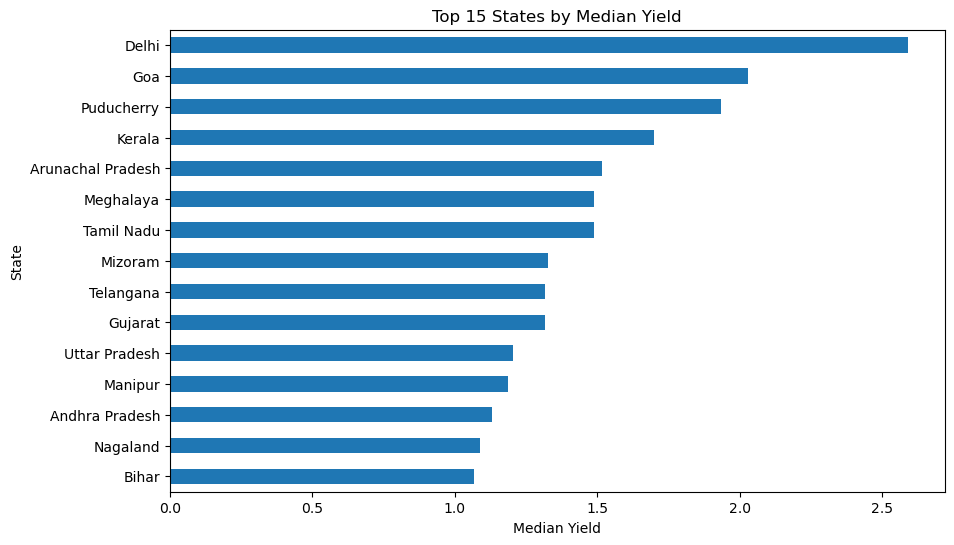

In [38]:
# Plot the 15 states with the highest median yield
plt.figure(figsize=(10, 6))

state_yield["median"].head(15).sort_values().plot(kind="barh")

plt.title("Top 15 States by Median Yield")
plt.xlabel("Median Yield")
plt.ylabel("State")

plt.show()

In [39]:
# Separate input features and target
X = df.drop(columns=['Yield', 'Production'])
y = df['Yield']

# Remove extra spaces from categorical columns
for col in ['Crop', 'Season', 'State']:
    X[col] = X[col].str.strip()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)


Features:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']

Target:
Yield


In [40]:
# Use older years for training and recent years for testing
train = df[df['Crop_Year'] <= 2018]
test = df[df['Crop_Year'] > 2018]

# Create training features and target
X_train = train.drop(columns=['Yield', 'Production'])
y_train = train['Yield']

# Create testing features and target
X_test = test.drop(columns=['Yield', 'Production'])
y_test = test['Yield']

# Clean categorical values
for col in ['Crop', 'Season', 'State']:
    X_train[col] = X_train[col].str.strip()
    X_test[col] = X_test[col].str.strip()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 18573
Testing rows: 1116


In [41]:
# Check the years used in each dataset
print("Training years:", X_train['Crop_Year'].min(), "to", X_train['Crop_Year'].max())
print("Testing years:", X_test['Crop_Year'].min(), "to", X_test['Crop_Year'].max())

Training years: 1997 to 2018
Testing years: 2019 to 2020


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_cols = ['Crop', 'Season', 'State']

numerical_cols = [
    'Crop_Year',
    'Area',
    'Annual_Rainfall',
    'Fertilizer',
    'Pesticide',
    'Avg_Temperature',
    'Max_Temperature',
    'Min_Temperature'
]

# Create an encoder for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Crop', 'Season', 'State']
Numerical columns: ['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


In [43]:
# Learn the encoding from training data and transform it
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform test data using the same encoding
X_test_encoded = preprocessor.transform(X_test)

print("Training shape:", X_train_encoded.shape)
print("Testing shape:", X_test_encoded.shape)

Training shape: (18573, 99)
Testing shape: (1116, 99)


In [44]:
# Check the type and dimensions of the encoded data
print("Encoded training type:", type(X_train_encoded))
print("Encoded training shape:", X_train_encoded.shape)

Encoded training type: <class 'scipy.sparse._csr.csr_matrix'>
Encoded training shape: (18573, 99)


In [45]:
from xgboost import XGBRegressor

# Create the XGBoost regression model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Train the model using the encoded training data
model.fit(X_train_encoded, y_train)

print("XGBoost model trained successfully!")


XGBoost model trained successfully!


In [46]:
# Predict crop yield for the unseen test years
y_pred = model.predict(X_test_encoded)

print("Predictions generated:", len(y_pred))
print("Actual values:", len(y_test))

Predictions generated: 1116
Actual values: 1116


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the model's prediction errors
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
----------------
MAE : 15.049042087280709
RMSE: 157.2069633787477
R²  : 0.9651991654104964


In [48]:
import pandas as pd

# Create a table comparing actual and predicted yield
results = pd.DataFrame({
    'Actual_Yield': y_test.values,
    'Predicted_Yield': y_pred
})

# Calculate the absolute prediction error
results['Absolute_Error'] = (
    results['Actual_Yield'] - results['Predicted_Yield']
).abs()

# Show the predictions with the largest errors
print(results.nlargest(15, 'Absolute_Error').to_string(index=False))

 Actual_Yield  Predicted_Yield  Absolute_Error
    16935.058     12502.945312     4432.112688
     9474.625     10967.793945     1493.168945
     6359.690      5090.878906     1268.811094
     7582.288      8607.753906     1025.465906
     8344.984      7340.130371     1004.853629
        0.000       829.600708      829.600708
    11918.291     12503.940430      585.649430
     8795.261      9362.887695      567.626695
     5882.037      6244.080566      362.043566
        5.552       249.823654      244.271654
      102.784      -123.313965      226.097965
        0.093       217.060867      216.967867
        0.471       216.704941      216.233941
        0.176       216.266083      216.090083
        2.170       217.045441      214.875441


In [49]:
# Add the original crop, season, state and year to the prediction results
results['Crop'] = X_test['Crop'].values
results['Season'] = X_test['Season'].values
results['State'] = X_test['State'].values
results['Crop_Year'] = X_test['Crop_Year'].values

# Show the observations with the largest prediction errors
print(
    results
    .nlargest(15, 'Absolute_Error')
    [['Crop', 'Season', 'State', 'Crop_Year',
      'Actual_Yield', 'Predicted_Yield', 'Absolute_Error']]
    .to_string(index=False)
)

        Crop     Season          State  Crop_Year  Actual_Yield  Predicted_Yield  Absolute_Error
     Coconut Whole Year Andhra Pradesh       2019     16935.058     12502.945312     4432.112688
     Coconut Whole Year     Puducherry       2019      9474.625     10967.793945     1493.168945
     Coconut Whole Year            Goa       2019      6359.690      5090.878906     1268.811094
     Coconut Whole Year          Assam       2019      7582.288      8607.753906     1025.465906
     Coconut Whole Year      Karnataka       2019      8344.984      7340.130371     1004.853629
     Coconut Whole Year   Chhattisgarh       2019         0.000       829.600708      829.600708
     Coconut Whole Year    West Bengal       2019     11918.291     12503.940430      585.649430
     Coconut Whole Year     Tamil Nadu       2019      8795.261      9362.887695      567.626695
     Coconut Whole Year         Kerala       2019      5882.037      6244.080566      362.043566
      Garlic Whole Year     Ta

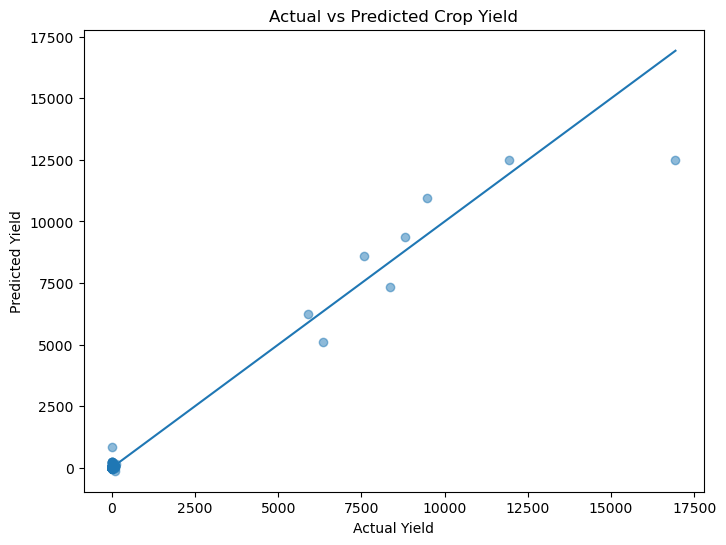

In [50]:
# Compare actual and predicted yield values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Add the ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

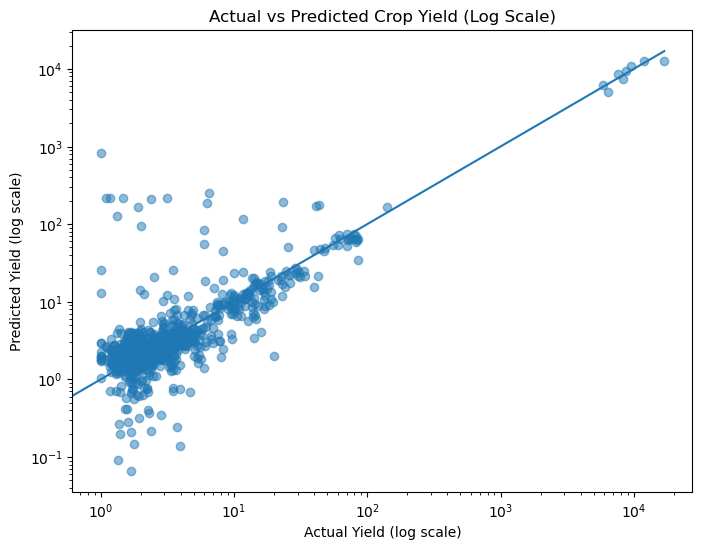

In [51]:
# Plot actual vs predicted using a log scale
plt.figure(figsize=(8, 6))

# Add 1 to avoid log(0)
plt.scatter(y_test + 1, y_pred + 1, alpha=0.5)

# Add the ideal prediction line
min_val = min((y_test + 1).min(), (y_pred + 1).min())
max_val = max((y_test + 1).max(), (y_pred + 1).max())

plt.plot([min_val, max_val], [min_val, max_val])

# Use logarithmic scales
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Yield (log scale)")
plt.ylabel("Predicted Yield (log scale)")
plt.title("Actual vs Predicted Crop Yield (Log Scale)")

plt.show()

cat__Crop_Coconut          0.745440
cat__Crop_Groundnut        0.041442
cat__State_Puducherry      0.036724
cat__State_Karnataka       0.029479
cat__State_Chhattisgarh    0.025177
                             ...   
cat__Crop_Cowpea(Lobia)    0.000000
cat__Crop_Moth             0.000000
cat__Crop_Small millets    0.000000
cat__Crop_Linseed          0.000000
cat__Crop_Niger seed       0.000000
Length: 99, dtype: float32


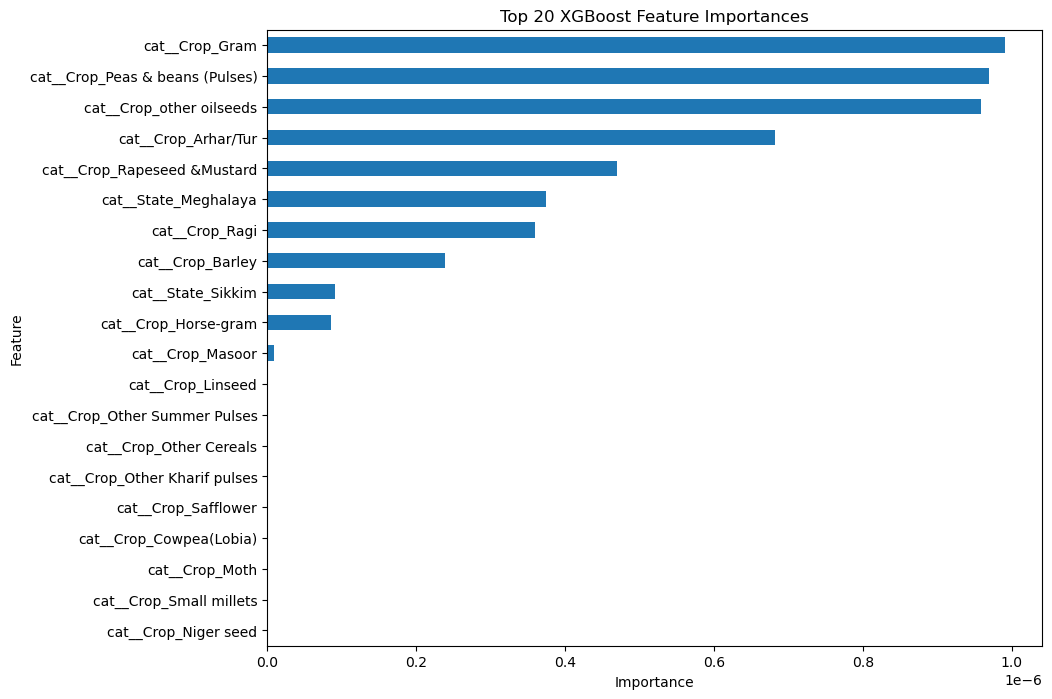

In [52]:
# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Match feature names with XGBoost importance values
importance = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance)

# Plot the most important features
plt.figure(figsize=(10, 8))

importance.tail(20).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")

plt.show()

In [53]:
# Check how strongly numerical features are related to yield
correlation = df[numerical_cols + ["Yield"]].corr()["Yield"].sort_values(ascending=False)

print(correlation)

Yield              1.000000
Min_Temperature    0.057606
Avg_Temperature    0.039341
Annual_Rainfall    0.020761
Max_Temperature    0.018742
Fertilizer         0.002862
Crop_Year          0.002539
Area               0.001858
Pesticide          0.001782
Name: Yield, dtype: float64


cat    0.958733
num    0.041267
dtype: float64


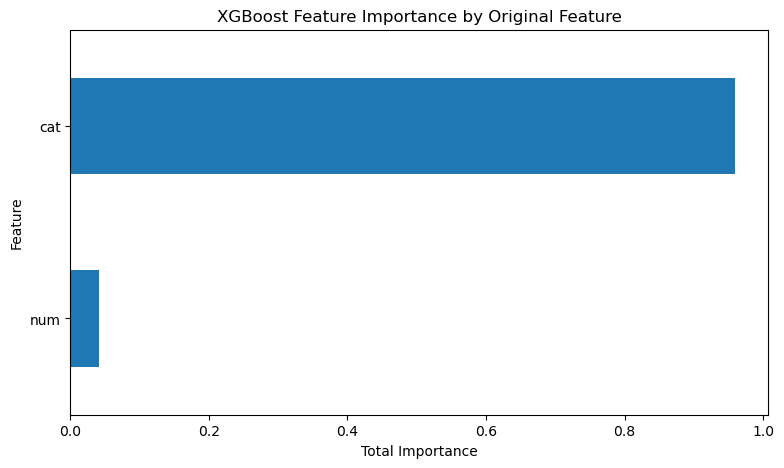

In [54]:
# Get importance of every encoded feature
feature_importance = pd.Series(
    model.feature_importances_,
    index=preprocessor.get_feature_names_out()
)

# Group one-hot features back to their original columns
grouped_importance = {}

for feature, importance_value in feature_importance.items():
    original_feature = feature.split("__")[0]
    grouped_importance[original_feature] = (
        grouped_importance.get(original_feature, 0) + importance_value
    )

# Sort features by total importance
grouped_importance = pd.Series(
    grouped_importance
).sort_values(ascending=False)

print(grouped_importance)

# Plot importance of the original features
plt.figure(figsize=(9, 5))

grouped_importance.sort_values().plot(kind="barh")

plt.xlabel("Total Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance by Original Feature")

plt.show()

In [55]:
# Get importance for each encoded feature
feature_importance = pd.Series(
    model.feature_importances_,
    index=preprocessor.get_feature_names_out()
)

# Separate categorical and numerical importance
cat_importance = feature_importance[
    feature_importance.index.str.startswith("cat__")
]

num_importance = feature_importance[
    feature_importance.index.str.startswith("num__")
]

# Calculate total importance for each original numerical feature
num_grouped = {}

for feature, value in num_importance.items():
    original_feature = feature.replace("num__", "")
    num_grouped[original_feature] = value

# Print numerical feature importance
print("Numerical Feature Importance:")
print(
    pd.Series(num_grouped)
    .sort_values(ascending=False)
)

# Calculate importance for each categorical feature
cat_grouped = {}

for feature, value in cat_importance.items():
    # Remove the cat__ prefix
    feature = feature.replace("cat__", "")

    # Identify which original categorical column it belongs to
    for column in categorical_cols:
        if feature.startswith(column + "_"):
            cat_grouped[column] = cat_grouped.get(column, 0) + value
            break

print("\nCategorical Feature Importance:")
print(
    pd.Series(cat_grouped)
    .sort_values(ascending=False)
)

Numerical Feature Importance:
Area               0.012172
Annual_Rainfall    0.007294
Avg_Temperature    0.007193
Fertilizer         0.006190
Min_Temperature    0.004355
Pesticide          0.001666
Max_Temperature    0.001278
Crop_Year          0.001119
dtype: float64

Categorical Feature Importance:
Crop      0.809562
State     0.144178
Season    0.004993
dtype: float64


In [56]:
# Calculate prediction error for every test observation
results = X_test.copy()

results["Actual_Yield"] = y_test.values
results["Predicted_Yield"] = y_pred
results["Absolute_Error"] = abs(
    results["Actual_Yield"] - results["Predicted_Yield"]
)

# Calculate MAE for each crop
crop_mae = (
    results.groupby("Crop")["Absolute_Error"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "MAE"})
    .sort_values("MAE", ascending=False)
)

print(crop_mae.head(15))

              count          MAE
Crop                            
Coconut           9  1285.481407
Cardamom          3    77.025719
Arecanut          8    45.013165
Black pepper      8    40.754673
Sugarcane        27    22.873930
Garlic           15    20.402849
Cashewnut         8    20.033029
Coriander        13    19.827879
Onion            28    18.620721
Banana           11    16.770157
Tapioca          11    15.823368
Turmeric         18    14.527389
Tobacco          21    12.728072
Dry chillies     20    10.493679
Sweet potato     18     7.986861


In [57]:
# Calculate percentage error for each prediction
import numpy as np

results = test.copy()

results["Actual_Yield"] = y_test.values
results["Predicted_Yield"] = y_pred

# Avoid division by zero when calculating percentage error
results["Percentage_Error"] = (
    np.abs(results["Actual_Yield"] - results["Predicted_Yield"])
    / np.maximum(np.abs(results["Actual_Yield"]), 1e-6)
) * 100

print(results[
    ["Crop", "State", "Crop_Year",
     "Actual_Yield", "Predicted_Yield", "Percentage_Error"]
].head(15))

               Crop           State  Crop_Year  Actual_Yield  Predicted_Yield  \
5761       Arecanut  Andhra Pradesh       2019         7.253         1.446381   
5762      Arhar/Tur  Andhra Pradesh       2019         0.440         1.214278   
5763      Arhar/Tur  Andhra Pradesh       2019         0.430         0.893471   
5764          Bajra  Andhra Pradesh       2019         2.005         1.313116   
5765          Bajra  Andhra Pradesh       2019         2.480         1.072800   
5766         Banana  Andhra Pradesh       2019        60.000        71.719589   
5767   Black pepper  Andhra Pradesh       2019         1.000        92.210258   
5768      Cashewnut  Andhra Pradesh       2019         1.000       -16.417152   
5769    Castor seed  Andhra Pradesh       2019         0.762         1.733976   
5770    Castor seed  Andhra Pradesh       2019         0.684         1.204144   
5771        Coconut  Andhra Pradesh       2019     16935.058     12502.945312   
5772      Coriander  Andhra 

In [58]:
# Calculate average percentage error
mape = results["Percentage_Error"].mean()

print("MAPE:", mape, "%")

MAPE: 78567837.82708275 %


In [59]:
# Calculate percentage error separately for each crop
crop_mape = (
    results.groupby("Crop")["Percentage_Error"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(crop_mape.head(15))

                     count          mean
Crop                                    
Coconut                  9  9.217786e+09
Other Kharif pulses     22  1.132475e+08
Guar seed                6  5.282695e+07
Potato                  36  3.296947e+07
Sannhamp                 8  2.281784e+07
Mesta                   11  1.791474e+07
Jute                     9  8.136399e+06
Safflower               10  7.851241e+06
Linseed                 15  5.893023e+06
Wheat                   27  3.719620e+06
Moong(Green Gram)       44  1.255605e+05
Cardamom                 3  8.490732e+04
Black pepper             8  1.712319e+04
Cashewnut                8  5.590279e+03
Coriander               13  3.875635e+03


In [60]:
# Calculate MAPE only for rows with meaningful non-zero actual yield
import numpy as np

# Keep only rows where actual yield is greater than zero
mask = y_test > 0

# Calculate percentage error for valid rows
percentage_error = (
    np.abs((y_test[mask] - y_pred[mask]) / y_test[mask]) * 100
)

# Calculate the average percentage error
mape = percentage_error.mean()

print("MAPE excluding zero yields:", mape, "%")
print("Rows used:", mask.sum())
print("Rows excluded:", (~mask).sum())

MAPE excluding zero yields: 593.2017730610022 %
Rows used: 1103
Rows excluded: 13


In [61]:
# Calculate MAE, RMSE and R² separately for each crop
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Create a dataframe containing actual and predicted values
evaluation = X_test.copy()

evaluation["Actual_Yield"] = y_test.values
evaluation["Predicted_Yield"] = y_pred

# Calculate metrics for every crop
crop_metrics = []

for crop, group in evaluation.groupby("Crop"):
    mae = mean_absolute_error(group["Actual_Yield"], group["Predicted_Yield"])
    rmse = np.sqrt(mean_squared_error(
        group["Actual_Yield"],
        group["Predicted_Yield"]
    ))
    
    # Calculate R² only when enough variation exists
    if len(group) > 1 and group["Actual_Yield"].nunique() > 1:
        r2 = r2_score(
            group["Actual_Yield"],
            group["Predicted_Yield"]
        )
    else:
        r2 = np.nan

    crop_metrics.append([crop, len(group), mae, rmse, r2])

# Convert results into a dataframe
crop_metrics = pd.DataFrame(
    crop_metrics,
    columns=["Crop", "Count", "MAE", "RMSE", "R2"]
)

# Sort crops by MAE
crop_metrics = crop_metrics.sort_values("MAE", ascending=False)

print(crop_metrics.head(15).to_string(index=False))

        Crop  Count         MAE        RMSE            R2
     Coconut      9 1285.481407 1732.976479  8.393632e-01
    Cardamom      3   77.025719  125.479875 -5.046538e+07
    Arecanut      8   45.013165   84.749109 -6.030097e+02
Black pepper      8   40.754673   83.044345 -1.564169e+04
   Sugarcane     27   22.873930   49.396960 -1.486799e+00
      Garlic     15   20.402849   63.440480 -4.747105e+02
   Cashewnut      8   20.033029   45.368429 -9.737821e+03
   Coriander     13   19.827879   60.429603 -2.771382e+03
       Onion     28   18.620721   40.305102 -2.091203e+01
      Banana     11   16.770157   41.127455 -2.704803e+00
     Tapioca     11   15.823368   39.405833 -9.771433e+00
    Turmeric     18   14.527389   43.748369 -7.203334e+01
     Tobacco     21   12.728072   45.627260 -7.647982e+02
Dry chillies     20   10.493679   37.271674 -7.574259e+01
Sweet potato     18    7.986861   15.077712 -6.165384e+00


In [62]:
# Check how the target yield is distributed across ranges

bins = [0, 1, 5, 10, 50, 100, 1000, 5000, 10000, np.inf]
labels = [
    "0-1",
    "1-5",
    "5-10",
    "10-50",
    "50-100",
    "100-1000",
    "1000-5000",
    "5000-10000",
    "10000+"
]

# Divide yield values into ranges
yield_ranges = pd.cut(
    df["Yield"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count rows in each range
distribution = yield_ranges.value_counts().sort_index()

print(distribution)

Yield
0-1           9572
1-5           7033
5-10          1194
10-50         1346
50-100         340
100-1000        40
1000-5000       21
5000-10000      79
10000+          64
Name: count, dtype: int64


In [63]:
# Create a log-transformed version of the yield target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Check the transformed target
print("Original target range:", y_train.min(), "to", y_train.max())
print("Log target range:", y_train_log.min(), "to", y_train_log.max())

Original target range: 0.0 to 21105.0
Log target range: 0.0 to 9.957312639231036


In [64]:
from xgboost import XGBRegressor

# Create XGBoost model for the log-transformed target
log_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train the model using log-transformed yield
log_model.fit(X_train_encoded, y_train_log)

print("Log-target XGBoost model trained successfully!")

Log-target XGBoost model trained successfully!


In [65]:
# Predict log-transformed yield for the test data
y_pred_log = log_model.predict(X_test_encoded)

# Convert predictions back to the original yield scale
y_pred_original = np.expm1(y_pred_log)

# Prevent negative yield predictions
y_pred_original = np.maximum(y_pred_original, 0)

print("Predictions generated:", len(y_pred_original))

Predictions generated: 1116


In [66]:
# Evaluate the log-target model on the original yield scale

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
log_mae = mean_absolute_error(y_test, y_pred_original)

log_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_original)
)

log_r2 = r2_score(
    y_test,
    y_pred_original
)

print("Log-Target Model Evaluation")
print("---------------------------")
print("MAE :", log_mae)
print("RMSE:", log_rmse)
print("R²  :", log_r2)

Log-Target Model Evaluation
---------------------------
MAE : 14.161461532123626
RMSE: 232.99368369979183
R²  : 0.9235575853619891


In [67]:
# Compare both models on Coconut predictions

comparison = X_test.copy()

comparison["Actual"] = y_test.values
comparison["Original_Prediction"] = y_pred
comparison["Log_Prediction"] = y_pred_original

# Show only Coconut predictions
coconut_comparison = comparison[
    comparison["Crop"] == "Coconut"
].copy()

# Calculate errors for both models
coconut_comparison["Original_Error"] = abs(
    coconut_comparison["Actual"] -
    coconut_comparison["Original_Prediction"]
)

coconut_comparison["Log_Error"] = abs(
    coconut_comparison["Actual"] -
    coconut_comparison["Log_Prediction"]
)

print(
    coconut_comparison[
        [
            "State",
            "Crop_Year",
            "Actual",
            "Original_Prediction",
            "Log_Prediction",
            "Original_Error",
            "Log_Error"
        ]
    ].to_string(index=False)
)

         State  Crop_Year    Actual  Original_Prediction  Log_Prediction  Original_Error   Log_Error
Andhra Pradesh       2019 16935.058         12502.945312     9988.925781     4432.112688 6946.132219
    Puducherry       2019  9474.625         10967.793945    11101.855469     1493.168945 1627.230469
         Assam       2019  7582.288          8607.753906     7378.757324     1025.465906  203.530676
           Goa       2019  6359.690          5090.878906     5082.660156     1268.811094 1277.029844
     Karnataka       2019  8344.984          7340.130371     7233.301270     1004.853629 1111.682730
        Kerala       2019  5882.037          6244.080566     6878.949707      362.043566  996.912707
    Tamil Nadu       2019  8795.261          9362.887695    11196.504883      567.626695 2401.243883
  Chhattisgarh       2019     0.000           829.600708        0.000000      829.600708    0.000000
   West Bengal       2019 11918.291         12503.940430    11820.487305      585.649430   

In [69]:
# Save the trained XGBoost model
model.save_model("../models/yield_model.json")

print("Model saved successfully!")

Model saved successfully!


In [70]:
import joblib

# Save the preprocessing pipeline
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!
